In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits

In [2]:
digits = load_digits()

In [4]:
print(type(digits))
print(digits.keys())

<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


In [5]:
print(digits.data.shape)
print(digits.images.shape)
print(digits.target.shape)
print(digits.target_names)

(1797, 64)
(1797, 8, 8)
(1797,)
[0 1 2 3 4 5 6 7 8 9]


In [6]:
print(digits.data[0])

[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


In [7]:
print(digits.target[0])
print(digits.target[1])
print(digits.target[2])
print(digits.target[3])
print(digits.target[4])

0
1
2
3
4


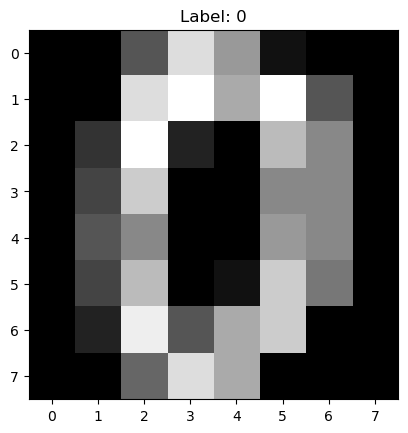

In [8]:
plt.imshow(digits.images[0], cmap="gray")
plt.title(f"Label: {digits.target[0]}")
plt.show()

In [9]:
np.bincount(digits.target)

array([178, 182, 177, 183, 181, 182, 181, 179, 174, 180])

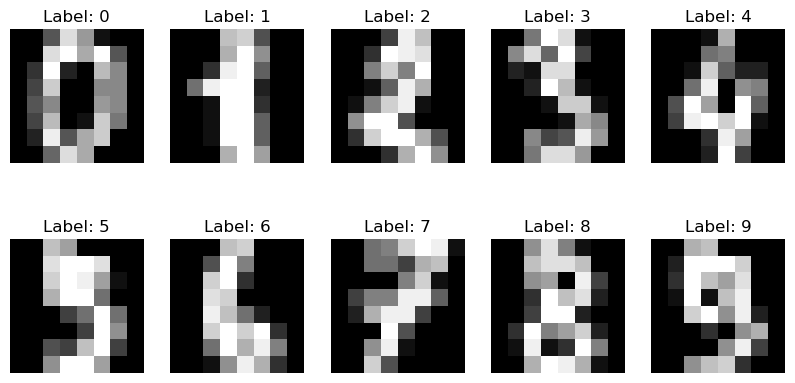

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis('off')
plt.show()

In [12]:
print(digits.data.min())

0.0


In [13]:
print(digits.data.max())

16.0


In [18]:
from sklearn.model_selection import train_test_split
X = digits.data
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1437, 64)
(360, 64)
(1437,)
(360,)


In [20]:
from sklearn.svm import SVC
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [21]:
train_score = svm_linear.score(X_train, y_train)
test_score = svm_linear.score(X_test, y_test)
print("Train Accuracy:", train_score)
print("Test Accuracy:", test_score)

Train Accuracy: 1.0
Test Accuracy: 0.9777777777777777


In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred = svm_linear.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9777777777777777
Confusion Matrix:
[[36  0  0  0  0  0  0  0  0  0]
 [ 0 34  0  0  0  0  0  0  1  1]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 36  0  0  0  0  0  1]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 35  0  1  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  3  0  0  0  0  0  1 31  0]
 [ 0  0  0  0  0  0  0  0  0 36]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      0.94      0.93        36
           2       1.00      1.00      1.00        35
           3       1.00      0.97      0.99        37
           4       1.00      1.00      1.00        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       0.97      1.00      0.99        36
           8       0.94      0.89      0.91        35
           9       0.95      1.00      0.97        36

   

In [25]:
from sklearn.svm import SVC
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train, y_train)

print("Train Accuracy:", svm_rbf.score(X_train, y_train))
print("Test Accuracy:", svm_rbf.score(X_test, y_test))

Train Accuracy: 0.9979123173277662
Test Accuracy: 0.9916666666666667


In [26]:
for c in [0.01, 0.1, 1, 10, 100]:
    model = SVC(kernel='rbf', C=c, random_state=42)
    model.fit(X_train, y_train)
    print("C =", c)
    print("Train Accuracy:", model.score(X_train, y_train))
    print("Test Accuracy:", model.score(X_test, y_test))
    print("-" * 40)

C = 0.01
Train Accuracy: 0.22616562282533054
Test Accuracy: 0.2222222222222222
----------------------------------------
C = 0.1
Train Accuracy: 0.9617258176757133
Test Accuracy: 0.9583333333333334
----------------------------------------
C = 1
Train Accuracy: 0.9979123173277662
Test Accuracy: 0.9916666666666667
----------------------------------------
C = 10
Train Accuracy: 1.0
Test Accuracy: 0.9944444444444445
----------------------------------------
C = 100
Train Accuracy: 1.0
Test Accuracy: 0.9944444444444445
----------------------------------------


In [27]:
for g in [0.0001, 0.001, 0.01, 0.1, 1]:
    model = SVC(kernel='rbf', C=1, gamma=g)
    model.fit(X_train, y_train)

    print("Gamma =", g)
    print("Train Accuracy:", model.score(X_train, y_train))
    print("Test Accuracy:", model.score(X_test, y_test))
    print("-" * 40)

Gamma = 0.0001
Train Accuracy: 0.9798190675017397
Test Accuracy: 0.9805555555555555
----------------------------------------
Gamma = 0.001
Train Accuracy: 0.9986082115518441
Test Accuracy: 0.9888888888888889
----------------------------------------
Gamma = 0.01
Train Accuracy: 1.0
Test Accuracy: 0.8472222222222222
----------------------------------------
Gamma = 0.1
Train Accuracy: 1.0
Test Accuracy: 0.11388888888888889
----------------------------------------
Gamma = 1
Train Accuracy: 1.0
Test Accuracy: 0.10277777777777777
----------------------------------------


final model...

In [29]:
from sklearn.svm import SVC

svm_final = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    random_state=42
)

svm_final.fit(X_train, y_train)

train_acc = svm_final.score(X_train, y_train)
test_acc = svm_final.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 0.9944444444444445


In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred = svm_final.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9944444444444445

Confusion Matrix:
[[36  0  0  0  0  0  0  0  0  0]
 [ 0 36  0  0  0  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  1  0  0  0  0  0  0 34  0]
 [ 0  0  0  0  0  0  0  1  0 35]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      1.00      0.99        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       1.00      1.00      1.00        36
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        36
           7       0.97      1.00      0.99        36
           8       1.00      0.97      0.99        35
           9       1.00      0.97      0.99        36

 

In [31]:
import joblib
joblib.dump(svm_final, "handwritten_digit_svm.pkl")
print("Model Saved Successfully!")

Model Saved Successfully!


In [32]:
y_pred = svm_final.predict(X_test)
wrong_idx = (y_pred != y_test)
print("Wrong Predictions:", wrong_idx.sum())

Wrong Predictions: 2


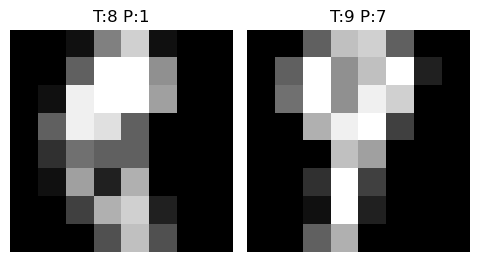

In [33]:
misclassified = np.where(y_pred != y_test)[0]
plt.figure(figsize=(12, 6))
for i, idx in enumerate(misclassified[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(8, 8), cmap='gray')
    plt.title(f"T:{y_test[idx]} P:{y_pred[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()